<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_048_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 48/365 — XGBoost
## How did Gradient Boosting become faster, more regularized, and practical for large tabular problems?

Yesterday we learned **Gradient Boosting**: build small trees sequentially so each new tree reduces the current model's remaining error.

Today we move to one of the most widely used implementations of that idea:

**XGBoost — Extreme Gradient Boosting**

XGBoost keeps the boosting idea, but adds engineering and mathematical improvements such as:

- regularization
- efficient tree construction
- row and column subsampling
- handling of sparse data
- parallelized computation in parts of training

In this notebook we compare:

1. scikit-learn `GradientBoostingClassifier`
2. `XGBClassifier`

using the built-in **Breast Cancer Wisconsin dataset**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, log_loss

try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError(
        "XGBoost is not installed. Install it once with: pip install xgboost"
    )


## 1. Load the dataset

This dataset is bundled with scikit-learn, so no runtime download is required.


In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Dataset shape:", X.shape)
print("Classes:", data.target_names)


Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


## 2. Baseline: classic Gradient Boosting


In [3]:
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

gb_train_pred = gb.predict(X_train)
gb_test_pred = gb.predict(X_test)

gb_train_acc = accuracy_score(y_train, gb_train_pred)
gb_test_acc = accuracy_score(y_test, gb_test_pred)

print("Gradient Boosting Train Accuracy:", round(gb_train_acc, 3))
print("Gradient Boosting Test Accuracy:", round(gb_test_acc, 3))


Gradient Boosting Train Accuracy: 1.0
Gradient Boosting Test Accuracy: 0.951


## 3. Train XGBoost

Important parameters:

- `n_estimators`: number of boosting rounds / trees
- `learning_rate`: contribution of each new tree
- `max_depth`: tree complexity
- `subsample`: fraction of training rows used by each boosting round
- `colsample_bytree`: fraction of features used by each tree
- `reg_lambda`: L2 regularization on leaf weights


In [4]:
xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

xgb_train_acc = accuracy_score(y_train, xgb_train_pred)
xgb_test_acc = accuracy_score(y_test, xgb_test_pred)

print("XGBoost Train Accuracy:", round(xgb_train_acc, 3))
print("XGBoost Test Accuracy:", round(xgb_test_acc, 3))


XGBoost Train Accuracy: 0.998
XGBoost Test Accuracy: 0.965


## 4. Compare the two models

This is not meant to prove XGBoost is always better.

The goal is to understand how two implementations of boosted trees behave on the same dataset.


,Model,Training Accuracy,Test Accuracy
0,Gradient Boosting,1.000,0.951
1,XGBoost,0.998,0.965


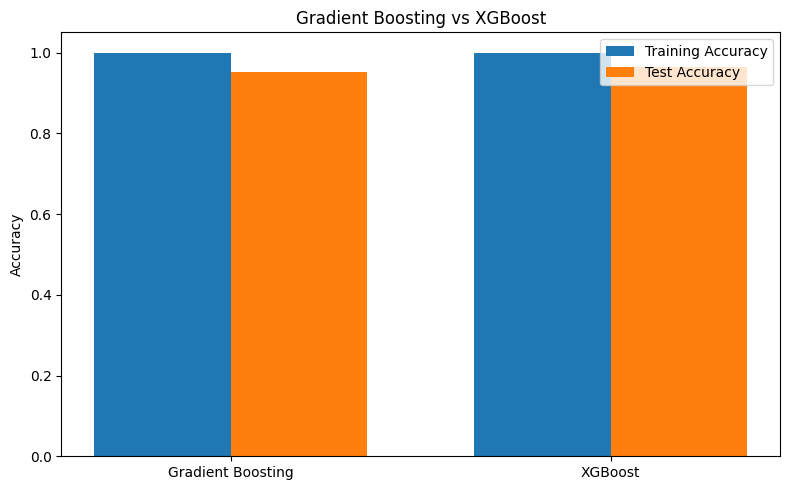

In [5]:
comparison = pd.DataFrame({
    "Model": ["Gradient Boosting", "XGBoost"],
    "Training Accuracy": [gb_train_acc, xgb_train_acc],
    "Test Accuracy": [gb_test_acc, xgb_test_acc]
})

display(comparison.round(3))

x = np.arange(len(comparison))

plt.figure(figsize=(8, 5))

plt.bar(
    x - 0.18,
    comparison["Training Accuracy"],
    width=0.36,
    label="Training Accuracy"
)

plt.bar(
    x + 0.18,
    comparison["Test Accuracy"],
    width=0.36,
    label="Test Accuracy"
)

plt.xticks(x, comparison["Model"])
plt.ylabel("Accuracy")
plt.title("Gradient Boosting vs XGBoost")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Watch XGBoost learn over boosting rounds

Because we supplied an `eval_set`, XGBoost stores the evaluation metric after each boosting round.

Here we plot **log loss**.

Lower log loss is better.


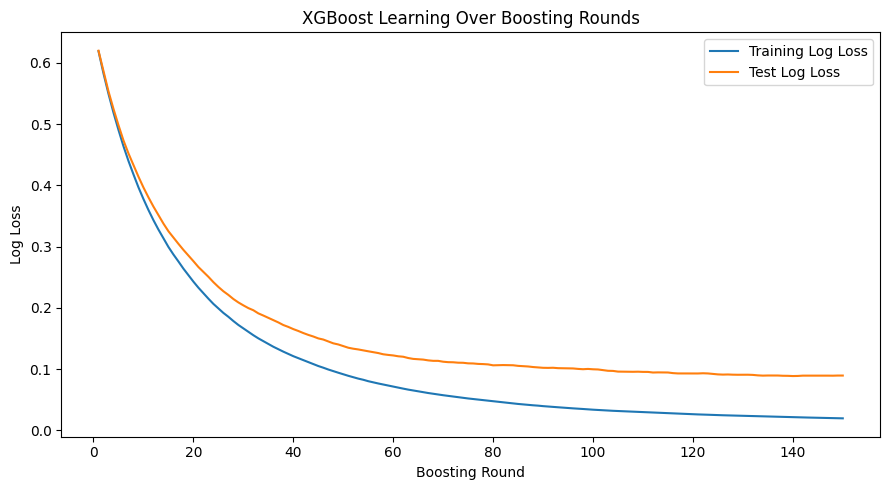

In [6]:
history = xgb.evals_result()

train_logloss = history["validation_0"]["logloss"]
test_logloss = history["validation_1"]["logloss"]

rounds = np.arange(1, len(train_logloss) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    rounds,
    train_logloss,
    label="Training Log Loss"
)

plt.plot(
    rounds,
    test_logloss,
    label="Test Log Loss"
)

plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Learning Over Boosting Rounds")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Why regularization matters

A boosted model can become very powerful.

That also means it can overfit.

XGBoost includes explicit regularization terms for tree complexity and leaf weights.

Conceptually, we can think of the objective as:

`Objective = Training Loss + Regularization`

So the algorithm does not only ask:

**How can I reduce prediction error?**

It also asks:

**Is this extra tree complexity worth it?**


## 7. Enterprise intuition

Imagine a credit-risk or fraud dataset with:

- hundreds of numerical and categorical-derived features
- nonlinear interactions
- missing values
- noisy signals
- millions of historical records

A single tree may be too unstable.

A basic boosted model can become powerful but expensive to tune and train.

XGBoost became popular for tabular ML because it combines boosting with:

- regularization
- efficient computation
- subsampling
- strong performance on structured/tabular datasets

Typical use cases include:

- fraud detection
- credit-risk scoring
- churn prediction
- claim severity / classification
- ranking
- demand prediction


## 8. Gradient Boosting vs XGBoost

### Gradient Boosting
Core algorithmic idea:
- sequentially add trees
- each new tree reduces the current loss

### XGBoost
An optimized boosting system that adds:
- regularization
- efficient split finding
- row subsampling
- column subsampling
- sparse-data optimizations
- parallelized parts of training

> XGBoost is not a completely different family of algorithm. It is an advanced implementation of gradient-boosted decision trees.


## What does this experiment teach?

- XGBoost is based on Gradient Boosting.
- Trees are still added sequentially.
- Regularization helps control model complexity.
- Row and feature subsampling can add useful randomness.
- Training/test loss across boosting rounds helps reveal overfitting.
- XGBoost is powerful, but it is not automatically the best model for every dataset.
- Hyperparameter tuning and proper validation remain essential.

> **Gradient Boosting gives us the idea. XGBoost turns that idea into a highly optimized and regularized tree-boosting system.**


## References

- XGBoost documentation:
  https://xgboost.readthedocs.io/en/stable/

- XGBoost parameters:
  https://xgboost.readthedocs.io/en/stable/parameter.html

- Chen & Guestrin (2016), XGBoost: A Scalable Tree Boosting System:
  https://arxiv.org/abs/1603.02754

- scikit-learn — Gradient Boosting:
  https://scikit-learn.org/stable/modules/ensemble.html#gradient-tree-boosting

- scikit-learn — Breast Cancer Wisconsin dataset:
  https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
